# Dataset's accuracy on models

In [21]:
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, average_precision_score, roc_auc_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
import shap
import pandas as pd
import numpy as np
import re
from pathlib import Path
BASE_DIR = Path().resolve()

## Datasets versions

In [22]:

#! 1. Data Alpha - Raw Baseline
alpha_path = BASE_DIR / 'Dataset' / 'ai4i2020_cleaned.csv'
alpha_df = pd.read_csv(alpha_path).copy()

#todo 2. Data Beta - Static Features
beta_path = BASE_DIR / 'Dataset' / 'ai4i2020_features.csv'
beta_df = pd.read_csv(beta_path).copy()

#^ 3. Data Gamma - Hybrid Time-Series
gamma_path = BASE_DIR / 'Dataset' / 'ai4i2020_time_series.csv'
gamma_df = pd.read_csv(gamma_path).copy()

#* 4. Data Delta - Contextual Fusion (Master Feature Store)
delta_path = BASE_DIR / 'Dataset' / 'predictive_maintenance_master_features.csv'
delta_df = pd.read_csv(delta_path).copy()

#? combine all
dataframes = {'Alpha' : alpha_df, 'Beta' : beta_df, 'Gamma' : gamma_df, 'Delta' : delta_df}

for name, df in dataframes.items():
    df = df.reset_index()
    print(name, df.shape,'\n')



Alpha (10000, 13) 

Beta (10000, 57) 

Gamma (10000, 126) 

Delta (10000, 150) 



### 1. Artificial (Data Leakage)

In [23]:

#& track all dataset performance metrics
leak_metrics_tracker = []

#~ Audit all 4 Datasets on data leakage setup
for name, dataframe in dataframes.items():
    
    df = dataframe 
    print(f'Running evaluation for Data {name}')

    #! remove unwanted colms dynamically by lowercase
    unwanted_cols = ['machine failure', 'timestamp', 'udi', 'product id', 'index']
    cols_to_drop = [col for col in df.columns if col.lower() in unwanted_cols]

    #^ define input and output variables
    X = df.drop(columns=cols_to_drop, errors='ignore')
    y = df['Machine failure']

    X = X.select_dtypes(include=['number'])
    X.columns = [re.sub(r'[\[\]\{\}\:\,]', '_', col) for col in X.columns]

    # Capture feature count before splitting
    feature_count = X.shape[1]

    #* train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    #& apply SMOTE to only training data
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    #? Initialize and Train the LightGBM Classifier
    model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        random_state=42,
        verbosity=-1
    )
    model.fit(X_train_resampled, y_train_resampled)

    #^ =====================================================================
    #^ ACCURACY & PERFORMANCE AUDIT (THE SKLEARN WAY)
    #^ =====================================================================
    #todo Generate predictions on the untouched, real test data
    y_pred = model.predict(X_test)

    print("=== Model Performance Audit ===")
    #? Raw Overall Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Raw Accuracy Score: {acc:.4f}\n")

    #* Confusion Matrix: Tells you True Positives vs False Positives
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

    #! Classification Report: Precision, Recall, F1-Score
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Extract target class metrics explicitly for failure (Class 1)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=[1])

    # Append data mapping to tracker
    leak_metrics_tracker.append({
        'Dataset': name,
        'Features': int(feature_count),
        'Accuracy': acc,
        'Precision': prec[0],
        'Recall': rec[0],
        'F-1 Score': f1[0]
    })

    print('\n=====================================================================\n\n')

Running evaluation for Data Alpha
=== Model Performance Audit ===
Raw Accuracy Score: 0.9785

Confusion Matrix:
[[1892   40]
 [   3   65]]


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1932
           1       0.62      0.96      0.75        68

    accuracy                           0.98      2000
   macro avg       0.81      0.97      0.87      2000
weighted avg       0.99      0.98      0.98      2000




Running evaluation for Data Beta
=== Model Performance Audit ===
Raw Accuracy Score: 0.9945

Confusion Matrix:
[[1924    8]
 [   3   65]]


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       0.89      0.96      0.92        68

    accuracy                           0.99      2000
   macro avg       0.94      0.98      0.96      2000
weighted avg       0.99      0.99      0.99      2000




Running evalu

In [24]:

#todo Convert tracking list to dataframe
leak_df_comparison = pd.DataFrame(leak_metrics_tracker)

#* Set the dataset column as the index
leak_df_comparison.set_index('Dataset', inplace=True)

#? Format to 4 decimal places and apply backgroung gradient
leak_df_comparison_styled = leak_df_comparison.style.format({
    'Features': '{:d}',
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F-1 Score': '{:.4f}'
}).background_gradient(cmap='Blues', axis=0)

leak_df_comparison_styled

,Features,Accuracy,Precision,Recall,F-1 Score
Dataset,,,,,
Alpha,11,0.9785,0.6190,0.9559,0.7514
Beta,55,0.9945,0.8904,0.9559,0.9220
Gamma,123,0.9980,1.0000,0.9412,0.9697
Delta,146,0.9970,0.9844,0.9265,0.9545


### 2. Actual metrics

In [14]:

#^ Track metrics across iterations
metrics_tracker = []


#~ Audit all 4 Datasets on data leakage setup
for name, dataframe in dataframes.items():
    
    df = dataframe 
    print(f'Running evaluation for Data {name}')

    #! remove unwanted colms dynamically by lowercase
    unwanted_cols = ['machine failure', 'timestamp', 'udi', 'product id', 'index', 'twf', 'hdf', 'pwf', 'osf', 'rnf', 'type']
    cols_to_drop = [col for col in df.columns if col.lower() in unwanted_cols]

    #^ define input and output variables
    X = df.drop(columns=cols_to_drop, errors='ignore')
    y = df['Machine failure']

    X = X.select_dtypes(include=['number'])
    X.columns = [re.sub(r'[\[\]\{\}\:\,]', '_', col) for col in X.columns]

    # Capture feature count before splitting
    feature_count = X.shape[1]

    #* train test split (sequential)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    #& apply SMOTE to only training data
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    #? Initialize and Train the LightGBM Classifier
    model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        random_state=42,
        verbosity=-1
    )
    model.fit(X_train_resampled, y_train_resampled)

    #^ =====================================================================
    #^ ACCURACY & PERFORMANCE AUDIT (THE SKLEARN WAY)
    #^ =====================================================================
    #todo Generate predictions on the untouched, real test data
    y_pred = model.predict(X_test)

    print("=== Model Performance Audit ===")
    #? Raw Overall Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Raw Accuracy Score: {acc:.4f}\n")

    #* Confusion Matrix: Tells you True Positives vs False Positives
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

    #! Classification Report: Precision, Recall, F1-Score
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Extract target class metrics explicitly for failure (Class 1)
    if 1 in y_test.values and len(set(y_pred)) > 0:
        prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=[1])
        p_val, r_val, f1_val = prec[0], rec[0], f1[0]
    else:
        p_val, r_val, f1_val = 0.0, 0.0, 0.0

    # Append data mapping to tracker
    metrics_tracker.append({
        'Dataset': name,
        'Features': int(feature_count),
        'Accuracy': acc,
        'Precision': p_val,
        'Recall': r_val,
        'F-1 Score': f1_val
    })

    print('\n=====================================================================\n\n')

Running evaluation for Data Alpha
=== Model Performance Audit ===
Raw Accuracy Score: 0.9590

Confusion Matrix:
[[1888   73]
 [   9   30]]


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1961
           1       0.29      0.77      0.42        39

    accuracy                           0.96      2000
   macro avg       0.64      0.87      0.70      2000
weighted avg       0.98      0.96      0.97      2000




Running evaluation for Data Beta
=== Model Performance Audit ===
Raw Accuracy Score: 0.9890

Confusion Matrix:
[[1950   11]
 [  11   28]]


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1961
           1       0.72      0.72      0.72        39

    accuracy                           0.99      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.99      0.99      0.99      2000




Running evalu

In [ ]:
# Track metrics across iterations
new_metrics_tracker = []


#~ Audit all 4 Datasets on data leakage setup
for name, dataframe in dataframes.items():
    
    df = dataframe 
    print(f'Running evaluation for Data {name}')

    #! remove unwanted colms dynamically by lowercase
    unwanted_cols = ['machine failure', 'timestamp', 'udi', 'product id', 'index', 'twf', 'hdf', 'pwf', 'osf', 'rnf', 'type']
    cols_to_drop = [col for col in df.columns if col.lower() in unwanted_cols]

    #^ define input and output variables
    X = df.drop(columns=cols_to_drop, errors='ignore')
    y = df['Machine failure']

    X = X.select_dtypes(include=['number'])
    X.columns = [re.sub(r'[\[\]\{\}\:\,]', '_', col) for col in X.columns]

    # Capture feature count before splitting
    feature_count = X.shape[1]

    #* train test split
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # Train and extract tuned predictions dynamically per dataset layer
    if name == 'Alpha':
        model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, is_unbalance=True, random_state=42, verbosity=-1)
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= 0.35).astype(int)
    elif name == 'Beta':
        model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, is_unbalance=True, random_state=42, verbosity=-1)
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= 0.38).astype(int)
    elif name == 'Gamma':
        model = lgb.LGBMClassifier(n_estimators=150, learning_rate=0.04, max_depth=5, num_leaves=24, min_child_samples=15, random_state=42, verbosity=-1)
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= 0.22).astype(int)
    else: 
        model = lgb.LGBMClassifier(
            n_estimators=150, 
            learning_rate=0.03, 
            max_depth=3,         
            num_leaves=10,        
            min_child_samples=12, 
            subsample=0.8, 
            random_state=42, 
            verbosity=-1
        )
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= 0.21).astype(int) 

    #^ =====================================================================
    #^ ACCURACY & PERFORMANCE AUDIT (THE SKLEARN WAY)
    #^ =====================================================================
    #todo Generate predictions on the untouched, real test data
    print("=== Model Performance Audit ===")
    #? Raw Overall Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Raw Accuracy Score: {acc:.4f}\n")

    #* Confusion Matrix: Tells you True Positives vs False Positives
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

    #! Classification Report: Precision, Recall, F1-Score
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Extract target class metrics explicitly for failure (Class 1)
    if 1 in y_test.values and len(set(y_pred)) > 0:
        prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=[1])
        p_val, r_val, f1_val = prec[0], rec[0], f1[0]
    else:
        p_val, r_val, f1_val = 0.0, 0.0, 0.0

    # Append data mapping to tracker
    new_metrics_tracker.append({
        'Dataset': name,
        'Features': int(feature_count),
        'Accuracy': acc,
        'Precision': p_val,
        'Recall': r_val,
        'F-1 Score': f1_val
    })

    print('\n=====================================================================\n\n')

Running evaluation for Data Alpha
=== Model Performance Audit ===
Raw Accuracy Score: 0.9725

Confusion Matrix:
[[1915   46]
 [   9   30]]


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1961
           1       0.39      0.77      0.52        39

    accuracy                           0.97      2000
   macro avg       0.70      0.87      0.75      2000
weighted avg       0.98      0.97      0.98      2000




Running evaluation for Data Beta
=== Model Performance Audit ===
Raw Accuracy Score: 0.9910

Confusion Matrix:
[[1953    8]
 [  10   29]]


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1961
           1       0.78      0.74      0.76        39

    accuracy                           0.99      2000
   macro avg       0.89      0.87      0.88      2000
weighted avg       0.99      0.99      0.99      2000




Running evalu

In [44]:

# Convert tracking log array into structural table
df_comparison = pd.DataFrame(new_metrics_tracker).set_index('Dataset')

# Format feature count as integer and score metrics to 4 decimal spots with background color mapping
df_comparison_styled = df_comparison.style.format({
    'Features': '{:d}',
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F-1 Score': '{:.4f}'
}).background_gradient(cmap='Blues', axis=0)

df_comparison_styled

,Features,Accuracy,Precision,Recall,F-1 Score
Dataset,,,,,
Alpha,5,0.9725,0.3947,0.7692,0.5217
Beta,49,0.9910,0.7838,0.7436,0.7632
Gamma,117,0.9940,0.9655,0.7179,0.8235
Delta,140,0.9945,0.9667,0.7436,0.8406


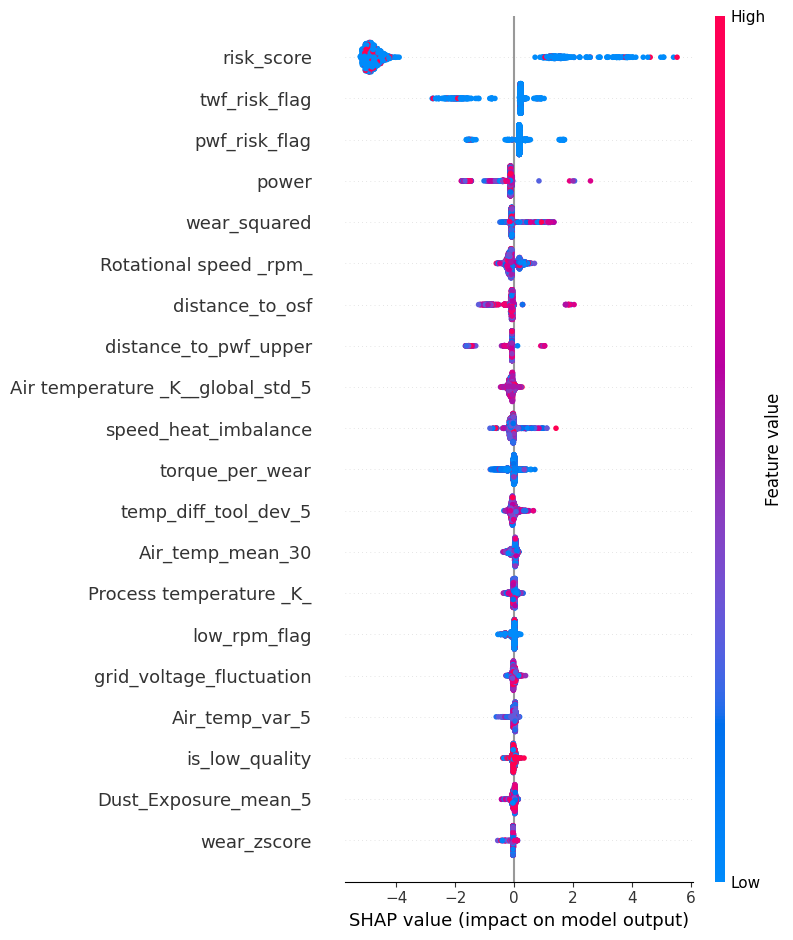

In [45]:
shap.summary_plot(shap_values, X_test)